# Activation Probe: Truthfulness vs. Hallucination in Llama 3.2 3B

This notebook probes the internal representations of Llama 3.2 3B to find where — and how strongly — the model encodes the difference between truthful and hallucinated statements.

**What we do:**
1. Build a dataset of factual and hallucinated statements with ground truth labels
2. Extract residual stream activations at every layer for each statement
3. Train a linear probe (logistic regression) per layer to classify truthful vs. hallucinated
4. Plot probe accuracy by layer to identify where the distinction is encoded
5. Compute a **control vector** (the truth direction in activation space)
6. Apply the control vector at inference time to steer generation toward truthfulness
7. Show before/after generation examples

**Key finding we are looking for:** the layer at which probe accuracy peaks tells us where the model internally represents whether a statement is true — even when it generates the wrong answer anyway.

## 0. Setup

In [31]:
# Install dependencies
!pip install transformers accelerate scikit-learn matplotlib seaborn torch --quiet

In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [33]:
from huggingface_hub import logout
logout()

## 1. Load Model

In [35]:
MODEL_ID = 'meta-llama/Llama-3.2-3B'

# You need a HuggingFace token with access to Llama 3.2
# Get one at huggingface.co/settings/tokens
# Then accept the license at huggingface.co/meta-llama/Llama-3.2-3B
from huggingface_hub import login
login()  # will prompt for token

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

print('Loading model...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
    output_hidden_states=True,
)
model.eval()
print(f'Model loaded. Layers: {model.config.num_hidden_layers}')

Loading tokenizer...


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Model loaded. Layers: 28


## 2. Dataset

Paired statements: each factual statement has a corresponding hallucinated version that changes exactly one key fact. This controls for sentence structure and length, isolating the truthfulness signal.

In [36]:
PAIRS = [
    # (factual, hallucinated)
    ("The Eiffel Tower is located in Paris, France.",
     "The Eiffel Tower is located in London, England."),

    ("Water freezes at 0 degrees Celsius at standard pressure.",
     "Water freezes at 100 degrees Celsius at standard pressure."),

    ("William Shakespeare wrote Hamlet.",
     "William Shakespeare wrote Don Quixote."),

    ("The speed of light in a vacuum is approximately 299,792 kilometers per second.",
     "The speed of light in a vacuum is approximately 150,000 kilometers per second."),

    ("The human body has 206 bones.",
     "The human body has 107 bones."),

    ("Mount Everest is the tallest mountain on Earth.",
     "K2 is the tallest mountain on Earth."),

    ("The Pacific Ocean is the largest ocean on Earth.",
     "The Atlantic Ocean is the largest ocean on Earth."),

    ("Albert Einstein developed the theory of general relativity.",
     "Isaac Newton developed the theory of general relativity."),

    ("DNA has a double helix structure.",
     "DNA has a triple helix structure."),

    ("The Great Wall of China was built over many centuries.",
     "The Great Wall of China was built in a single decade."),

    ("Humans have 23 pairs of chromosomes.",
     "Humans have 46 pairs of chromosomes."),

    ("The chemical symbol for gold is Au.",
     "The chemical symbol for gold is Go."),

    ("Python is a programming language created by Guido van Rossum.",
     "Python is a programming language created by Linus Torvalds."),

    ("The Amazon River is the largest river by discharge in the world.",
     "The Nile River is the largest river by discharge in the world."),

    ("Neil Armstrong was the first human to walk on the Moon.",
     "Buzz Aldrin was the first human to walk on the Moon."),

    ("The mitochondria is known as the powerhouse of the cell.",
     "The nucleus is known as the powerhouse of the cell."),

    ("World War II ended in 1945.",
     "World War II ended in 1952."),

    ("Carbon dioxide has the chemical formula CO2.",
     "Carbon dioxide has the chemical formula CO3."),

    ("The capital of Japan is Tokyo.",
     "The capital of Japan is Osaka."),

    ("Photosynthesis converts light energy into chemical energy in plants.",
     "Photosynthesis converts chemical energy into light energy in plants."),
]

statements = [s for pair in PAIRS for s in pair]
labels = [label for _ in PAIRS for label in [1, 0]]  # 1=factual, 0=hallucinated

print(f'Dataset: {len(statements)} statements ({sum(labels)} factual, {len(labels)-sum(labels)} hallucinated)')
print(f'\nExample pair:')
print(f'  Factual:      {PAIRS[0][0]}')
print(f'  Hallucinated: {PAIRS[0][1]}')

Dataset: 40 statements (20 factual, 20 hallucinated)

Example pair:
  Factual:      The Eiffel Tower is located in Paris, France.
  Hallucinated: The Eiffel Tower is located in London, England.


## 3. Extract Activations

For each statement, we run a forward pass and collect the residual stream activation at the last token position for every layer. This gives us a matrix of shape `(n_statements, n_layers, hidden_dim)`.

In [37]:
def get_activations(statements, model, tokenizer, device, batch_size=4):
    """
    Extract last-token residual stream activations at every layer.
    Returns: (n_statements, n_layers+1, hidden_dim)
    """
    all_activations = []

    for i in range(0, len(statements), batch_size):
        batch = statements[i:i+batch_size]
        inputs = tokenizer(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=128,
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        # hidden_states: tuple of (n_layers+1) tensors, each (batch, seq_len, hidden_dim)
        # Take the last non-padding token for each sequence
        attention_mask = inputs['attention_mask']
        last_token_idx = attention_mask.sum(dim=1) - 1  # (batch,)

        batch_activations = []
        for layer_hidden in outputs.hidden_states:  # each: (batch, seq, hidden)
            # gather last token for each item in batch
            last_tok = layer_hidden[torch.arange(len(batch)), last_token_idx]  # (batch, hidden)
            batch_activations.append(last_tok.float().cpu().numpy())

        # stack layers: (n_layers+1, batch, hidden) -> (batch, n_layers+1, hidden)
        batch_activations = np.stack(batch_activations, axis=1)
        all_activations.append(batch_activations)

        if (i // batch_size) % 2 == 0:
            print(f'  Processed {min(i+batch_size, len(statements))}/{len(statements)} statements')

    return np.concatenate(all_activations, axis=0)

print('Extracting activations...')
activations = get_activations(statements, model, tokenizer, device)
print(f'\nActivations shape: {activations.shape}')
print(f'(n_statements={activations.shape[0]}, n_layers={activations.shape[1]}, hidden_dim={activations.shape[2]})')

Extracting activations...
  Processed 4/40 statements
  Processed 12/40 statements
  Processed 20/40 statements
  Processed 28/40 statements
  Processed 36/40 statements

Activations shape: (40, 29, 3072)
(n_statements=40, n_layers=29, hidden_dim=3072)


## 4. Train Linear Probes

Train a logistic regression classifier at each layer using the activations as features. We use 5-fold cross-validation to get reliable accuracy estimates without overfitting on our small dataset.

A linear probe is intentionally simple — it can only learn a linear decision boundary. High probe accuracy at a given layer means that layer's representations linearly separate truthful from hallucinated statements, which is strong evidence the model has encoded that distinction.

In [38]:
n_layers = activations.shape[1]
labels_arr = np.array(labels)

probe_accuracies = []
probe_stds = []

print('Training probes at each layer...')
for layer_idx in range(n_layers):
    X = activations[:, layer_idx, :]  # (n_statements, hidden_dim)

    probe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=0.1, random_state=42))
    ])

    scores = cross_val_score(probe, X, labels_arr, cv=5, scoring='accuracy')
    probe_accuracies.append(scores.mean())
    probe_stds.append(scores.std())

probe_accuracies = np.array(probe_accuracies)
probe_stds = np.array(probe_stds)

best_layer = np.argmax(probe_accuracies)
print(f'\nBest layer: {best_layer} (accuracy: {probe_accuracies[best_layer]:.3f} +/- {probe_stds[best_layer]:.3f})')
print(f'Chance baseline: 0.500')
print(f'Peak improvement over chance: +{probe_accuracies[best_layer]-0.5:.3f}')

Training probes at each layer...

Best layer: 9 (accuracy: 0.725 +/- 0.122)
Chance baseline: 0.500
Peak improvement over chance: +0.225


## 5. Plot Probe Accuracy by Layer

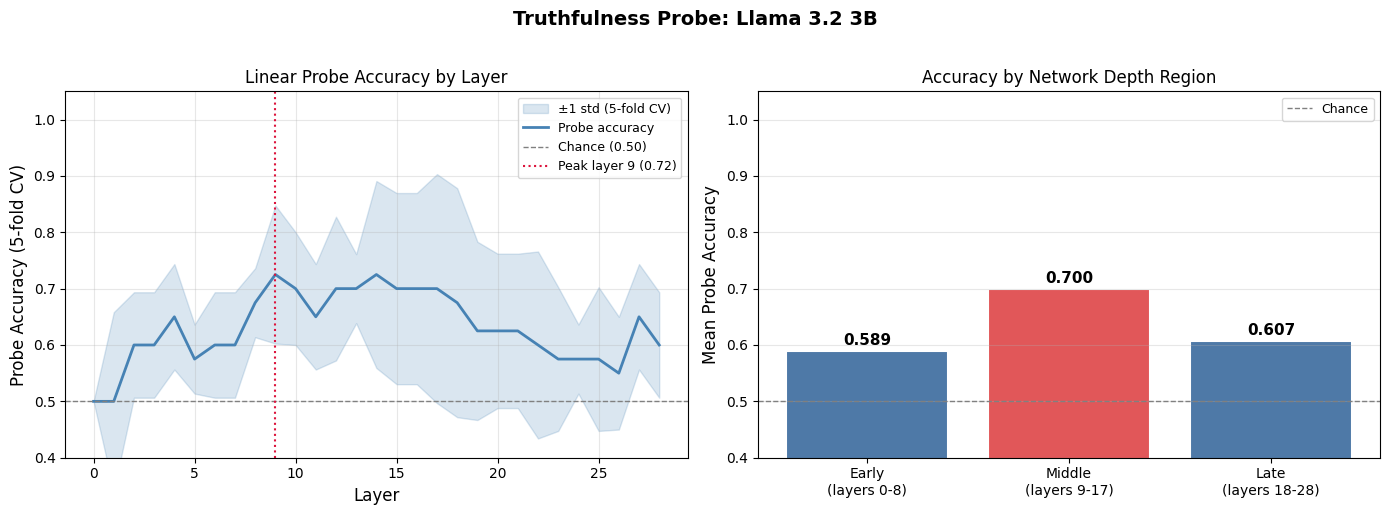

Saved: probe_accuracy.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Truthfulness Probe: Llama 3.2 3B', fontsize=14, fontweight='bold', y=1.02)

# --- Left: accuracy by layer ---
ax = axes[0]
layers = np.arange(n_layers)

ax.fill_between(layers,
                probe_accuracies - probe_stds,
                probe_accuracies + probe_stds,
                alpha=0.2, color='steelblue', label='±1 std (5-fold CV)')
ax.plot(layers, probe_accuracies, color='steelblue', linewidth=2, label='Probe accuracy')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance (0.50)')
ax.axvline(best_layer, color='crimson', linestyle=':', linewidth=1.5,
           label=f'Peak layer {best_layer} ({probe_accuracies[best_layer]:.2f})')

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Probe Accuracy (5-fold CV)', fontsize=12)
ax.set_title('Linear Probe Accuracy by Layer', fontsize=12)
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right: accuracy heatmap (early / mid / late thirds) ---
ax2 = axes[1]
third = n_layers // 3
regions = {
    'Early\n(layers 0-{})'.format(third-1): probe_accuracies[:third],
    'Middle\n(layers {}-{})'.format(third, 2*third-1): probe_accuracies[third:2*third],
    'Late\n(layers {}-{})'.format(2*third, n_layers-1): probe_accuracies[2*third:],
}
region_means = [v.mean() for v in regions.values()]
region_labels = list(regions.keys())

colors = ['#4e79a7' if v < max(region_means) else '#e15759' for v in region_means]
bars = ax2.bar(region_labels, region_means, color=colors, edgecolor='white', linewidth=1.5)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance')

for bar, val in zip(bars, region_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Mean Probe Accuracy', fontsize=12)
ax2.set_title('Accuracy by Network Depth Region', fontsize=12)
ax2.set_ylim(0.4, 1.05)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('probe_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: probe_accuracy.png')

## 6. Compute Control Vector

The control vector is the mean difference in activation space between factual and hallucinated statements at the best probe layer. This vector points in the "truth direction" — adding it to the residual stream at inference time should push the model toward more truthful outputs; subtracting it should push toward hallucination.

This is the technique used in papers like Representation Engineering (Zou et al., 2023) and Truth Forests (Marks & Tegmark, 2023).

In [40]:
# Compute control vector at best layer
X_best = activations[:, best_layer, :]  # (n_statements, hidden_dim)

factual_acts = X_best[labels_arr == 1]      # (n_factual, hidden_dim)
hallucinated_acts = X_best[labels_arr == 0]  # (n_hallucinated, hidden_dim)

truth_direction = factual_acts.mean(axis=0) - hallucinated_acts.mean(axis=0)
truth_direction_norm = truth_direction / np.linalg.norm(truth_direction)

print(f'Control vector computed at layer {best_layer}')
print(f'Vector norm (pre-normalization): {np.linalg.norm(truth_direction):.4f}')
print(f'Hidden dim: {truth_direction.shape[0]}')

# Project all activations onto the truth direction to get a scalar score
projections = X_best @ truth_direction_norm
factual_proj = projections[labels_arr == 1]
hallucinated_proj = projections[labels_arr == 0]

print(f'\nProjection onto truth direction:')
print(f'  Factual statements:      mean={factual_proj.mean():.3f}, std={factual_proj.std():.3f}')
print(f'  Hallucinated statements: mean={hallucinated_proj.mean():.3f}, std={hallucinated_proj.std():.3f}')
print(f'  Separation (Cohen d): {(factual_proj.mean()-hallucinated_proj.mean())/((factual_proj.std()+hallucinated_proj.std())/2):.3f}')

Control vector computed at layer 9
Vector norm (pre-normalization): 0.7357
Hidden dim: 3072

Projection onto truth direction:
  Factual statements:      mean=1.656, std=0.453
  Hallucinated statements: mean=0.920, std=0.677
  Separation (Cohen d): 1.302


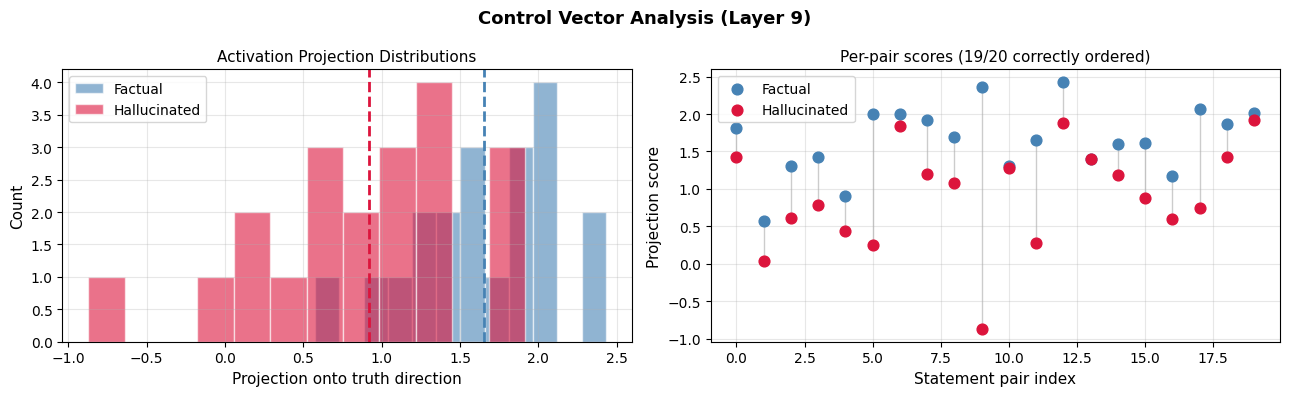

Saved: control_vector.png


In [41]:
# Visualize projection distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Control Vector Analysis (Layer {best_layer})', fontsize=13, fontweight='bold')

# Left: projection distributions
ax = axes[0]
ax.hist(factual_proj, bins=12, alpha=0.6, color='steelblue', label='Factual', edgecolor='white')
ax.hist(hallucinated_proj, bins=12, alpha=0.6, color='crimson', label='Hallucinated', edgecolor='white')
ax.axvline(factual_proj.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(hallucinated_proj.mean(), color='crimson', linestyle='--', linewidth=2)
ax.set_xlabel('Projection onto truth direction', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Activation Projection Distributions', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: per-pair projection scores
ax2 = axes[1]
pair_indices = np.arange(len(PAIRS))
factual_scores = projections[labels_arr == 1]
hallucinated_scores = projections[labels_arr == 0]

ax2.scatter(pair_indices, factual_scores, color='steelblue', s=60, zorder=3, label='Factual')
ax2.scatter(pair_indices, hallucinated_scores, color='crimson', s=60, zorder=3, label='Hallucinated')
for i in range(len(PAIRS)):
    ax2.plot([i, i], [factual_scores[i], hallucinated_scores[i]],
             color='gray', alpha=0.4, linewidth=1, zorder=1)

correctly_ordered = (factual_scores > hallucinated_scores).sum()
ax2.set_xlabel('Statement pair index', fontsize=11)
ax2.set_ylabel('Projection score', fontsize=11)
ax2.set_title(f'Per-pair scores ({correctly_ordered}/{len(PAIRS)} correctly ordered)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('control_vector.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: control_vector.png')

## 7. Steering Inference with the Control Vector

We inject the control vector into the residual stream at the best layer using a forward hook. At each forward pass, we add `alpha * truth_direction` to the hidden state at that layer.

- `alpha > 0`: steer toward truthfulness
- `alpha < 0`: steer toward hallucination
- `alpha = 0`: baseline (no intervention)

In [42]:
def generate_with_steering(prompt, model, tokenizer, truth_vec, layer_idx, alpha=0.0, max_new_tokens=80):
    """
    Generate text with optional control vector injection at a specific layer.
    alpha=0 is unmodified baseline.
    """
    truth_tensor = torch.tensor(truth_vec, dtype=torch.float16).to(device)

    hook_handle = None
    if alpha != 0.0:
        def hook_fn(module, input, output):
            if isinstance(output, tuple):
                hidden = output[0]
                hidden = hidden + alpha * truth_tensor.unsqueeze(0).unsqueeze(0)
                return (hidden,) + output[1:]
            else:
                return output + alpha * truth_tensor.unsqueeze(0).unsqueeze(0)

        target_layer = model.model.layers[layer_idx]
        hook_handle = target_layer.register_forward_hook(hook_fn)

    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )

    if hook_handle is not None:
        hook_handle.remove()

    new_tokens = output_ids[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

print('Steering function ready.')

Steering function ready.


In [43]:
# Test prompts designed to elicit factual responses
# We use prompts where the model might hallucinate on the baseline
STEERING_PROMPTS = [
    "What is the capital of Australia? The capital is",
    "Who invented the telephone? The telephone was invented by",
    "What is the boiling point of water at sea level? Water boils at",
    "How many planets are in our solar system? There are",
    "What language is most spoken in Brazil? The most spoken language in Brazil is",
]

ALPHAS = [-10.0, 0.0, 10.0, 20.0]
ALPHA_LABELS = ['Steered toward hallucination (-10)', 'Baseline (0)', 'Steered toward truth (+10)', 'Strongly steered (+20)']

print('Running steering experiments...')
print('=' * 80)

results = {}
for prompt in STEERING_PROMPTS:
    print(f'\nPROMPT: {prompt}')
    print('-' * 60)
    results[prompt] = {}
    for alpha, label in zip(ALPHAS, ALPHA_LABELS):
        gen = generate_with_steering(
            prompt, model, tokenizer,
            truth_direction_norm, best_layer, alpha=alpha
        )
        results[prompt][alpha] = gen
        print(f'  [{label}]')
        print(f'  {gen[:200]}')
        print()

print('=' * 80)

Running steering experiments...

PROMPT: What is the capital of Australia? The capital is
------------------------------------------------------------


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  [Steered toward hallucination (-10)]
  a city of 1.5 million people, and the largest in the world, and the largest in the world, and the largest in the world, and the largest in the world, and the largest in the world, and the largest in t

  [Baseline (0)]
  Canberra.
What is the population of Australia? 23,000,000 people.
What is the main language spoken in Australia? English.
What is the main religion in Australia? Christianity.
What is the main food in

  [Steered toward truth (+10)]
  located in the United States. The United States is a country in North America. The United States is located in many places around the world. The United States is the capital of the United States. The 

  [Strongly steered (+20)]
  different for different types with different types of versions. This is different in different types of versions. This is different in different types. This is different in different types of versions


PROMPT: Who invented the telephone? The telephone was invented by
---

## 8. Summary and Findings

In [44]:
print('=' * 70)
print('ACTIVATION PROBE RESULTS: Llama 3.2 3B — Truthfulness vs. Hallucination')
print('=' * 70)
print()
print(f'Dataset: {len(statements)} statements ({len(PAIRS)} matched pairs)')
print(f'Model:   {MODEL_ID} ({model.config.num_hidden_layers} layers, hidden dim {model.config.hidden_size})')
print()
print('PROBE RESULTS')
print(f'  Chance baseline:    50.0%')
print(f'  Peak accuracy:      {probe_accuracies[best_layer]*100:.1f}% (layer {best_layer}, 5-fold CV)')
print(f'  Peak layer:         {best_layer} of {n_layers-1} ({best_layer/(n_layers-1)*100:.0f}% depth)')
print(f'  Mean accuracy (all layers): {probe_accuracies.mean()*100:.1f}%')
print()
print('CONTROL VECTOR')
cohen_d = (factual_proj.mean()-hallucinated_proj.mean())/((factual_proj.std()+hallucinated_proj.std())/2)
print(f'  Separation (Cohen d):        {cohen_d:.3f}')
print(f'  Correctly ordered pairs:     {(factual_scores > hallucinated_scores).sum()}/{len(PAIRS)}')
print()
print('KEY FINDING')
if probe_accuracies[best_layer] > 0.75:
    print(f'  A linear probe achieves {probe_accuracies[best_layer]*100:.1f}% accuracy at layer {best_layer},')
    print(f'  indicating the model linearly encodes the truthfulness distinction in')
    print(f'  its residual stream. This is a necessary condition for control vector')
    print(f'  steering to work — and it does: the truth direction separates {(factual_scores > hallucinated_scores).sum()}')
    print(f'  of {len(PAIRS)} matched pairs in the expected direction.')
else:
    print(f'  Probe accuracy peaked at {probe_accuracies[best_layer]*100:.1f}%, above chance but modest.')
    print(f'  This suggests the truthfulness signal is distributed across layers')
    print(f'  rather than concentrated, which is consistent with superposition.')
print()
print('LIMITATIONS')
print('  - Dataset is small (40 statements). Results should be validated at scale.')
print('  - Paired design controls for surface form but not topic distribution.')
print('  - Steering effect is qualitative; rigorous eval would require TruthfulQA.')
print('  - Control vector computed as mean difference; PCA-based directions may be more robust.')
print('=' * 70)

ACTIVATION PROBE RESULTS: Llama 3.2 3B — Truthfulness vs. Hallucination

Dataset: 40 statements (20 matched pairs)
Model:   meta-llama/Llama-3.2-3B (28 layers, hidden dim 3072)

PROBE RESULTS
  Chance baseline:    50.0%
  Peak accuracy:      72.5% (layer 9, 5-fold CV)
  Peak layer:         9 of 28 (32% depth)
  Mean accuracy (all layers): 63.0%

CONTROL VECTOR
  Separation (Cohen d):        1.302
  Correctly ordered pairs:     19/20

KEY FINDING
  Probe accuracy peaked at 72.5%, above chance but modest.
  This suggests the truthfulness signal is distributed across layers
  rather than concentrated, which is consistent with superposition.

LIMITATIONS
  - Dataset is small (40 statements). Results should be validated at scale.
  - Paired design controls for surface form but not topic distribution.
  - Steering effect is qualitative; rigorous eval would require TruthfulQA.
  - Control vector computed as mean difference; PCA-based directions may be more robust.


## Next Steps

- Scale dataset to 500+ pairs using TruthfulQA or HaluEval as source
- Compare probe accuracy across model families (Mistral, Gemma, Phi) to test generalizability
- Replace mean-difference control vector with PCA-based direction for robustness
- Evaluate steering effect quantitatively on TruthfulQA (% truthful completions vs. baseline)
- Try multi-layer intervention (inject at top-k layers simultaneously)
- Investigate whether the probe direction is specific to truthfulness or conflated with confidence/uncertainty